# Atividade: Comparação de Modelos de Classificação

## Objetivo

- Comparar os seguintes modelos de classificação:
  * Árvore de Decisão com poda
  * K Vizinhos mais Próximos (KNN)
  * Regressão Logística
  * Floresta Aleatória
- Escolher o melhor modelo com base no desempenho em validação
- Avaliar o melhor modelo no conjunto de teste

## Etapas da atividade

1. **Carregar o dataset** `dataset_classificacao.csv`  ✅
   - Use: `pandas.read_csv("dataset_classificacao.csv")`

2. **Separar os dados em treino, validação e teste** (60%, 20%, 20%) ✅ 
   - Use: `sklearn.model_selection.train_test_split` duas vezes:  
     Primeiro para separar treino+validação de teste,  
     Depois para separar treino de validação.

3. **Treinar os seguintes modelos:**

   a) **Árvore de Decisão com poda por complexidade** ✅ (optuna and cost_complexity_ppruning_path)
      - Use: `sklearn.tree.DecisionTreeClassifier`  
      - Para poda: use o método `cost_complexity_pruning_path`  
      - Varra diferentes valores de `ccp_alpha` e escolha o melhor na validação  

   b) **KNN (K-Nearest Neighbors)** ✅
      - Use: `sklearn.neighbors.KNeighborsClassifier`  
      - Teste para `k = 3, 5, 10, 20`

   c) **Regressão Logística (sem ajustar hiperparâmetros)** ✅
      - Use: `sklearn.linear_model.LogisticRegression` com os parâmetros padrão  

   d) **Floresta Aleatória** ✅
      - Use: `sklearn.ensemble.RandomForestClassifier`  
      - Fixe `n_estimators=100`  
      - Teste combinações de `criterion = ['gini', 'entropy']` e `max_features = ['sqrt', 'log2', None]`

4. **Para cada modelo (usando apenas o conjunto de validação), calcule:** ✅
   - Acurácia: `sklearn.metrics.accuracy_score`
   - Precisão: `sklearn.metrics.precision_score`
   - Recall: `sklearn.metrics.recall_score`
   - F1-score: `sklearn.metrics.f1_score`

5. **Monte uma tabela** (`pandas.DataFrame`) com uma linha por modelo e colunas: ✅
   `'acuracia'`, `'precisao'`, `'recall'`, `'f1'`

6. **Escolha o melhor modelo com base nas métricas de validação.** ✅ 
   - Avalie esse único modelo no conjunto de teste.  

7. **Exiba as importâncias usando Floresta Aleatória:** ✅
   - Mostre um gráfico com as 20 variáveis mais importantes  
   - Use: `modelo.feature_importances_`  
   - Para plotar: `matplotlib.pyplot.bar`

8. **Utilizando a informação encontrada no item anterior, quantas covariadas você acha que são de fato importantes para o problema?** 9 ✅

9.  **Utilizando apenas as 5 covariadas mais importantes encontradas no item anterior, rode todos os modelos novamente e compare os melhores modelos encontrados usando todas as covariadas e os melhores modelos encontrados usando apenas as 5 mais importantes. Discuta o resultado.** Usando F1 como criterio, o melhor modelo é o KNN ✅


# Imports

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

import optuna
import matplotlib.pyplot as plt
import seaborn as sns

# Data Processing

In [2]:
df = pd.read_csv("dataset_classificacao.csv")
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x491,x492,x493,x494,x495,x496,x497,x498,x499,target
0,0.991245,0.050748,-0.343749,0.274253,-1.518734,-0.159455,1.427896,1.926818,1.555172,-1.737581,...,0.226665,-0.147782,-0.024233,1.513658,0.928057,0.449303,0.071110,1.468139,0.208218,1
1,0.292069,0.962034,-2.349618,-0.440499,-0.494180,0.711639,1.408426,-0.238690,1.660926,0.674760,...,0.157092,0.509665,-1.661400,-0.502276,0.502979,-1.098843,-1.753755,2.173440,1.090410,0
2,-1.379857,-1.239205,1.616920,0.649324,-1.395141,0.643645,-0.374341,0.378370,1.182380,0.977513,...,-0.817294,-0.561936,0.638945,-0.571702,0.136797,0.895805,-0.958593,1.041268,0.464521,0
3,-0.162766,-0.510166,-0.348483,-0.166792,0.152929,-0.867810,-1.157489,-0.471870,0.932700,1.854919,...,-0.395616,0.160152,-1.308039,-0.635852,1.139097,0.661483,-0.041045,0.464849,-2.702643,0
4,1.381736,-0.332115,-1.061583,-0.585043,-0.299487,1.504501,0.698723,-0.959224,-0.796920,-0.386506,...,-1.890095,0.644228,-0.705502,0.426899,-0.153879,0.517804,1.003377,-0.582950,0.372384,1


In [3]:
TARGET = 'target'
FEATURES = [i for i in df.columns if i != TARGET]

In [4]:
X = df[FEATURES]
y = df[TARGET]

In [5]:
X_train, X_pre, y_train, y_pre = train_test_split(X, y, test_size=.40, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_pre, y_pre, test_size=.5, random_state=42)

In [6]:
print(X_train.shape, X_test.shape, X_val.shape)

(1200, 500) (400, 500) (400, 500)


# Decision Tree

## Define ccp using optuna

In [7]:
def objective(trial):
    tree = DecisionTreeClassifier(
        # Default
        criterion = 'gini',
        splitter = 'best',
        max_depth = None,
        min_samples_split = 2,
        min_samples_leaf = 1,
        min_weight_fraction_leaf = 0,
        max_features = None,
        max_leaf_nodes = None,
        min_impurity_decrease=0,
        class_weight=None,

        # Different from default
        random_state = 42,
        ccp_alpha = trial.suggest_float('ccp', 1e-8, 100, log=True)
    )

    tree.fit(X_train, y_train)
    pred = tree.predict(X_val)

    return accuracy_score(y_val, pred)

study_tree = optuna.create_study(direction='maximize')
study_tree.optimize(objective, n_trials=50)

[I 2025-05-20 17:50:11,598] A new study created in memory with name: no-name-f91c7d91-4b8a-4b20-a344-95b8bc5bc75e
[I 2025-05-20 17:50:11,850] Trial 0 finished with value: 0.815 and parameters: {'ccp': 0.00028940381510266406}. Best is trial 0 with value: 0.815.
[I 2025-05-20 17:50:12,087] Trial 1 finished with value: 0.865 and parameters: {'ccp': 0.008581334053934301}. Best is trial 1 with value: 0.865.
[I 2025-05-20 17:50:12,349] Trial 2 finished with value: 0.815 and parameters: {'ccp': 5.163889252382445e-05}. Best is trial 1 with value: 0.865.
[I 2025-05-20 17:50:12,588] Trial 3 finished with value: 0.815 and parameters: {'ccp': 0.00093052749484379}. Best is trial 1 with value: 0.865.
[I 2025-05-20 17:50:12,823] Trial 4 finished with value: 0.815 and parameters: {'ccp': 1.2198595799327645e-08}. Best is trial 1 with value: 0.865.
[I 2025-05-20 17:50:13,057] Trial 5 finished with value: 0.815 and parameters: {'ccp': 1.2205935210186752e-07}. Best is trial 1 with value: 0.865.
[I 2025-05

In [8]:
optuna.visualization.plot_slice(study_tree, params=["ccp"])

In [9]:
study_tree.best_params

{'ccp': 0.008581334053934301}

## Define ccp using cost complexity prune path

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

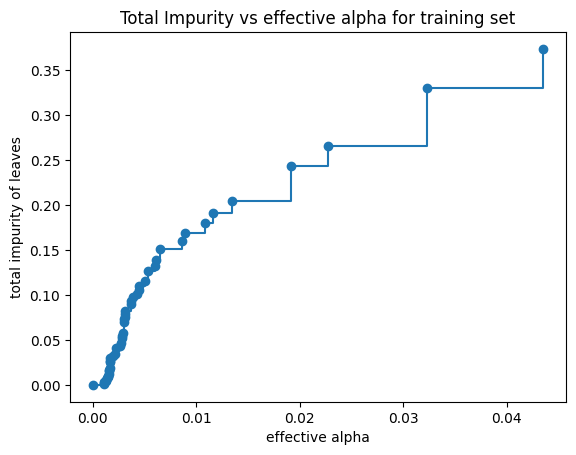

In [10]:
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

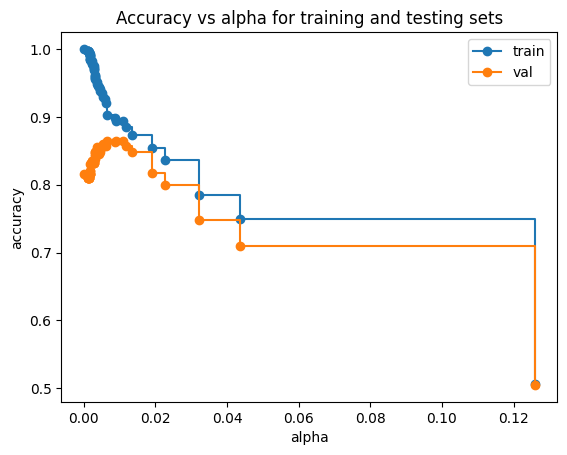

In [11]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_val, y_val) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="val", drawstyle="steps-post")
ax.legend()
plt.show()

In [12]:
results = dict()
for k, value in zip(ccp_alphas, test_scores):
    results[k] = value

max(results.items(), key=lambda x: x[1])

(0.006501550019197999, 0.865)

# KNN

In [13]:
def objective(trial):
    model = KNeighborsClassifier(n_neighbors=trial.suggest_int('neighbors', 1, 1200, log=True))
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    return accuracy_score(y_val, pred)


study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective, n_trials=50)

optuna.visualization.plot_slice(study_knn, params=["neighbors"])

[I 2025-05-20 17:50:36,091] A new study created in memory with name: no-name-5431abfc-b71a-406a-88f8-69633ce4f4ea
[I 2025-05-20 17:50:36,370] Trial 0 finished with value: 0.8 and parameters: {'neighbors': 35}. Best is trial 0 with value: 0.8.
[I 2025-05-20 17:50:36,424] Trial 1 finished with value: 0.7575 and parameters: {'neighbors': 447}. Best is trial 0 with value: 0.8.
[I 2025-05-20 17:50:36,438] Trial 2 finished with value: 0.71 and parameters: {'neighbors': 5}. Best is trial 0 with value: 0.8.
[I 2025-05-20 17:50:36,453] Trial 3 finished with value: 0.795 and parameters: {'neighbors': 79}. Best is trial 0 with value: 0.8.
[I 2025-05-20 17:50:36,472] Trial 4 finished with value: 0.7725 and parameters: {'neighbors': 306}. Best is trial 0 with value: 0.8.
[I 2025-05-20 17:50:36,485] Trial 5 finished with value: 0.6475 and parameters: {'neighbors': 2}. Best is trial 0 with value: 0.8.
[I 2025-05-20 17:50:36,501] Trial 6 finished with value: 0.7825 and parameters: {'neighbors': 83}. B

In [14]:
study_knn.best_params

{'neighbors': 45}

# Regressão Logistica

In [15]:
reg = LogisticRegression()
reg.fit(X_train, y_train)
pred = reg.predict(X_val)

print(accuracy_score(y_val, pred))

0.6325


# Random Forest

In [16]:
def objective(trial):

    tree = RandomForestClassifier(
        n_estimators=100,
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        random_state=42
    )

    tree.fit(X_train, y_train)
    pred = tree.predict(X_val)

    return accuracy_score(y_val, pred)

study_tree = optuna.create_study(direction='maximize')
study_tree.optimize(objective, n_trials=10)

[I 2025-05-20 17:50:37,393] A new study created in memory with name: no-name-e9075f40-bdfb-47aa-8c60-eacf2e74da06
[I 2025-05-20 17:50:53,061] Trial 0 finished with value: 0.875 and parameters: {'criterion': 'gini', 'max_features': None}. Best is trial 0 with value: 0.875.
[I 2025-05-20 17:51:08,654] Trial 1 finished with value: 0.875 and parameters: {'criterion': 'gini', 'max_features': None}. Best is trial 0 with value: 0.875.
[I 2025-05-20 17:51:09,023] Trial 2 finished with value: 0.78 and parameters: {'criterion': 'gini', 'max_features': 'log2'}. Best is trial 0 with value: 0.875.
[I 2025-05-20 17:51:09,478] Trial 3 finished with value: 0.8025 and parameters: {'criterion': 'entropy', 'max_features': 'log2'}. Best is trial 0 with value: 0.875.
[I 2025-05-20 17:51:24,901] Trial 4 finished with value: 0.875 and parameters: {'criterion': 'gini', 'max_features': None}. Best is trial 0 with value: 0.875.
[I 2025-05-20 17:51:25,788] Trial 5 finished with value: 0.795 and parameters: {'cri

In [17]:
optuna.visualization.plot_slice(study_tree, params=["criterion", 'max_features'])

In [18]:
study_tree.best_params

{'criterion': 'gini', 'max_features': None}

# Save table

In [19]:
results = dict()

tree = DecisionTreeClassifier(random_state=42, ccp_alpha=0.00793046026606327)
tree.fit(X_train, y_train)
results['decision_tree'] = dict()
results['decision_tree']['accuracy'] = accuracy_score(y_val, tree.predict(X_val))
results['decision_tree']['precision'] = precision_score(y_val, tree.predict(X_val))
results['decision_tree']['recall'] = recall_score(y_val, tree.predict(X_val))
results['decision_tree']['f1'] = f1_score(y_val, tree.predict(X_val))


knn = KNeighborsClassifier(n_neighbors=46)
knn.fit(X_train, y_train)
results['knn'] = dict()
results['knn']['accuracy'] = accuracy_score(y_val, knn.predict(X_val))
results['knn']['precision'] = precision_score(y_val, knn.predict(X_val))
results['knn']['recall'] = recall_score(y_val, knn.predict(X_val))
results['knn']['f1'] = f1_score(y_val, knn.predict(X_val))


logistic = LogisticRegression()
logistic.fit(X_train, y_train)
results['logistic'] = dict()
results['logistic']['accuracy'] = accuracy_score(y_val, logistic.predict(X_val))
results['logistic']['precision'] = precision_score(y_val, logistic.predict(X_val))
results['logistic']['recall'] = recall_score(y_val, logistic.predict(X_val))
results['logistic']['f1'] = f1_score(y_val, logistic.predict(X_val))


rf = RandomForestClassifier(random_state=42, criterion='entropy', max_features=None)
rf.fit(X_train, y_train)
results['rf'] = dict()
results['rf']['accuracy'] = accuracy_score(y_val, rf.predict(X_val))
results['rf']['precision'] = precision_score(y_val, rf.predict(X_val))
results['rf']['recall'] = recall_score(y_val, rf.predict(X_val))
results['rf']['f1'] = f1_score(y_val, rf.predict(X_val))


pd.DataFrame.from_dict(results, orient='index')

,accuracy,precision,recall,f1
decision_tree,0.8650,0.836364,0.910891,0.872038
knn,0.8250,0.786957,0.896040,0.837963
logistic,0.6325,0.629108,0.663366,0.645783
rf,0.8875,0.872038,0.910891,0.891041


<Axes: xlabel='importance', ylabel='feature'>

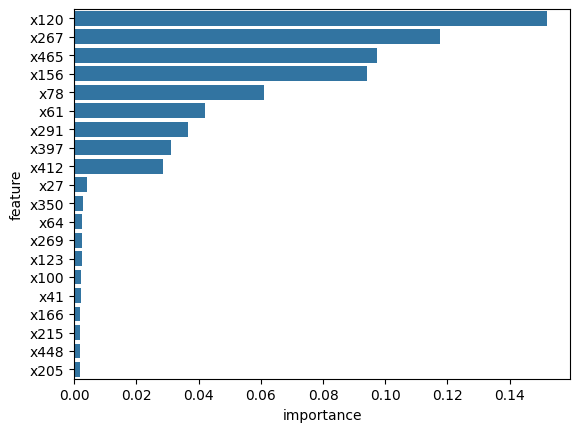

In [20]:
y = FEATURES
x = rf.feature_importances_
feature_importance = {k:v for k,v in zip(y, x)}
feature_importance = sorted(feature_importance.items(), key=lambda x: x[1])
feature_importance = feature_importance[::-1]

feature_importance = pd.DataFrame(feature_importance, columns=['feature', 'importance'])
feature_importance = feature_importance.head(20)
sns.barplot(data=feature_importance, x='importance', y='feature')

# Somente 9 features são importantes

## Now using less features

In [21]:
tree = DecisionTreeClassifier(random_state=42, ccp_alpha=0.00793046026606327)
tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.00793046026606327, random_state=42)

In [22]:
features_used = {k: v for k, v in zip(X_train.columns, tree.feature_importances_) if v != 0.0}
features_used

{'x61': 0.103743844295946,
 'x78': 0.1421856293538412,
 'x120': 0.36146110147779903,
 'x156': 0.025507014191694016,
 'x267': 0.13796662001148327,
 'x291': 0.03342453977132881,
 'x412': 0.07075424528342414,
 'x465': 0.12495700561448347}

In [23]:
def objective(trial):
    tree = DecisionTreeClassifier(
        # Default
        criterion = 'gini',
        splitter = 'best',
        max_depth = None,
        min_samples_split = 2,
        min_samples_leaf = 1,
        min_weight_fraction_leaf = 0,
        max_features = None,
        max_leaf_nodes = None,
        min_impurity_decrease=0,
        class_weight=None,

        # Different from default
        random_state = 42,
        ccp_alpha = trial.suggest_float('ccp', 1e-8, 100, log=True)
    )

    tree.fit(X_train, y_train)
    pred = tree.predict(X_val)

    return accuracy_score(y_val, pred)

study_tree = optuna.create_study(direction='maximize')
study_tree.optimize(objective, n_trials=50)

[I 2025-05-20 17:51:43,303] A new study created in memory with name: no-name-af466afe-b659-4bb1-8822-f9bb7e718291
[I 2025-05-20 17:51:43,572] Trial 0 finished with value: 0.505 and parameters: {'ccp': 71.07046511484174}. Best is trial 0 with value: 0.505.
[I 2025-05-20 17:51:43,816] Trial 1 finished with value: 0.815 and parameters: {'ccp': 1.0455248068803169e-05}. Best is trial 1 with value: 0.815.
[I 2025-05-20 17:51:44,075] Trial 2 finished with value: 0.505 and parameters: {'ccp': 8.24520492629812}. Best is trial 1 with value: 0.815.
[I 2025-05-20 17:51:44,322] Trial 3 finished with value: 0.815 and parameters: {'ccp': 1.9717953362423926e-05}. Best is trial 1 with value: 0.815.
[I 2025-05-20 17:51:44,568] Trial 4 finished with value: 0.815 and parameters: {'ccp': 0.000368009191198122}. Best is trial 1 with value: 0.815.
[I 2025-05-20 17:51:44,815] Trial 5 finished with value: 0.815 and parameters: {'ccp': 8.594011657661714e-07}. Best is trial 1 with value: 0.815.
[I 2025-05-20 17:5

In [24]:
def objective(trial):
    model = KNeighborsClassifier(n_neighbors=trial.suggest_int('neighbors', 1, 1200, log=True))
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    return accuracy_score(y_val, pred)


study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective, n_trials=50)

optuna.visualization.plot_slice(study_knn, params=["neighbors"])

[I 2025-05-20 17:51:55,761] A new study created in memory with name: no-name-f88459b4-ca88-491f-ada9-353cc5d60bb9
[I 2025-05-20 17:51:55,777] Trial 0 finished with value: 0.7625 and parameters: {'neighbors': 10}. Best is trial 0 with value: 0.7625.
[I 2025-05-20 17:51:55,792] Trial 1 finished with value: 0.6475 and parameters: {'neighbors': 2}. Best is trial 0 with value: 0.7625.
[I 2025-05-20 17:51:55,811] Trial 2 finished with value: 0.7725 and parameters: {'neighbors': 205}. Best is trial 2 with value: 0.7725.
[I 2025-05-20 17:51:55,824] Trial 3 finished with value: 0.7325 and parameters: {'neighbors': 3}. Best is trial 2 with value: 0.7725.
[I 2025-05-20 17:51:55,839] Trial 4 finished with value: 0.7775 and parameters: {'neighbors': 110}. Best is trial 4 with value: 0.7775.
[I 2025-05-20 17:51:55,855] Trial 5 finished with value: 0.8 and parameters: {'neighbors': 102}. Best is trial 5 with value: 0.8.
[I 2025-05-20 17:51:55,871] Trial 6 finished with value: 0.7825 and parameters: {

In [25]:
def objective(trial):

    tree = RandomForestClassifier(
        n_estimators=100,
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        random_state=42
    )

    tree.fit(X_train, y_train)
    pred = tree.predict(X_val)

    return accuracy_score(y_val, pred)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective, n_trials=10)

[I 2025-05-20 17:51:56,641] A new study created in memory with name: no-name-34b0f385-72c8-4025-b9cc-54c15fb1f77f
[I 2025-05-20 17:51:57,644] Trial 0 finished with value: 0.8125 and parameters: {'criterion': 'entropy', 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8125.
[I 2025-05-20 17:51:58,534] Trial 1 finished with value: 0.795 and parameters: {'criterion': 'gini', 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8125.
[I 2025-05-20 17:51:59,014] Trial 2 finished with value: 0.8025 and parameters: {'criterion': 'entropy', 'max_features': 'log2'}. Best is trial 0 with value: 0.8125.
[I 2025-05-20 17:51:59,905] Trial 3 finished with value: 0.795 and parameters: {'criterion': 'gini', 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8125.
[I 2025-05-20 17:52:00,367] Trial 4 finished with value: 0.8025 and parameters: {'criterion': 'entropy', 'max_features': 'log2'}. Best is trial 0 with value: 0.8125.
[I 2025-05-20 17:52:01,376] Trial 5 finished with value: 0.8125 

In [26]:
X = df[features_used.keys()]
y = df[TARGET]

X_train, X_pre, y_train, y_pre = train_test_split(X, y, test_size=.40, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_pre, y_pre, test_size=.5, random_state=42)


results = dict()

tree = DecisionTreeClassifier(random_state=42, ccp_alpha=0.001154855307190122)
tree.fit(X_train, y_train)
results['decision_tree'] = dict()
results['decision_tree']['accuracy'] = accuracy_score(y_val, tree.predict(X_val))
results['decision_tree']['precision'] = precision_score(y_val, tree.predict(X_val))
results['decision_tree']['recall'] = recall_score(y_val, tree.predict(X_val))
results['decision_tree']['f1'] = f1_score(y_val, tree.predict(X_val))


knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
results['knn'] = dict()
results['knn']['accuracy'] = accuracy_score(y_val, knn.predict(X_val))
results['knn']['precision'] = precision_score(y_val, knn.predict(X_val))
results['knn']['recall'] = recall_score(y_val, knn.predict(X_val))
results['knn']['f1'] = f1_score(y_val, knn.predict(X_val))


logistic = LogisticRegression()
logistic.fit(X_train, y_train)
results['logistic'] = dict()
results['logistic']['accuracy'] = accuracy_score(y_val, logistic.predict(X_val))
results['logistic']['precision'] = precision_score(y_val, logistic.predict(X_val))
results['logistic']['recall'] = recall_score(y_val, logistic.predict(X_val))
results['logistic']['f1'] = f1_score(y_val, logistic.predict(X_val))


rf = RandomForestClassifier(random_state=42, criterion='gini', max_features='log2')
rf.fit(X_train, y_train)
results['rf'] = dict()
results['rf']['accuracy'] = accuracy_score(y_val, rf.predict(X_val))
results['rf']['precision'] = precision_score(y_val, rf.predict(X_val))
results['rf']['recall'] = recall_score(y_val, rf.predict(X_val))
results['rf']['f1'] = f1_score(y_val, rf.predict(X_val))


pd.DataFrame.from_dict(results, orient='index')

,accuracy,precision,recall,f1
decision_tree,0.8900,0.903061,0.876238,0.889447
knn,0.9150,0.907767,0.925743,0.916667
logistic,0.7700,0.739130,0.841584,0.787037
rf,0.8975,0.888889,0.910891,0.899756
